# Hex-level evaluation

Loads and visualizes the TAZ/hex/ceiling metrics for a trained run. The actual
computation happens in `scripts/evaluate.py` - run that first, in a tmux
session (it's heavy enough that running it inside a notebook kernel kept
crashing):

```bash
python scripts/evaluate.py                    # evaluates the most recently trained run
python scripts/evaluate.py <path/to/run_dir>  # evaluates a specific run
```

This notebook just reads the `eval_results.pkl` it saves and plots it.

In [21]:
import glob
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qol_surrogate.data import TRANSPORT_MODES

In [22]:
MODELS_DIR = "../models"

# picks the most recently trained run - point this at a specific folder instead to load an older run
run_dirs = sorted(d for d in glob.glob(os.path.join(MODELS_DIR, "gcn_resnet_*")) if os.path.isdir(d))
run_dir = run_dirs[-1]
run_dir

'../models/gcn_resnet_20260810_174322'

In [23]:
results_path = os.path.join(run_dir, "eval_results.pkl")

if not os.path.exists(results_path):
    raise FileNotFoundError(
        f"{results_path} doesn't exist yet - run `python scripts/evaluate.py` "
        f"(e.g. in a tmux session) first, then re-run this cell."
    )

with open(results_path, "rb") as f:
    results = pickle.load(f)

if "ceiling" not in results:
    raise KeyError(
        f"{results_path} is from before the ceiling metric existed - "
        f"re-run `python scripts/evaluate.py` to regenerate it."
    )

print(f"Loaded evaluation from {results_path}")
results["taz"]["deviation"]["overall"], results["taz"]["absolute"]["overall"]

Loaded evaluation from ../models/gcn_resnet_20260810_174322/eval_results.pkl


({'r2': 0.9450612664222717,
  'mae': 18.86450958251953,
  'c_index': np.float64(0.9528254065038284),
  'wape': np.float32(0.12856607)},
 {'r2': 0.936316728591919,
  'mae': 18.86450958251953,
  'c_index': np.float64(0.9653713499913966),
  'wape': np.float32(0.10208039)})

## TAZ deviation, per channel

What the model is actually trained to predict: the flood-induced *change* in accessibility, per (mode, POI category).

In [24]:
deviation_table = pd.DataFrame({
    metric: {col: m[metric] for col, m in results["taz"]["deviation"]["per_channel"].items()}
    for metric in ("r2", "mae", "c_index", "wape")
})
deviation_table

,r2,mae,c_index,wape
cumulative_accessibility_CAR_cultural,0.988434,11.261590,0.957095,0.013128
cumulative_accessibility_CAR_education,0.101447,134.890182,0.846246,0.259496
cumulative_accessibility_CAR_green_space,0.629622,10.704675,0.786134,0.380264
cumulative_accessibility_CAR_health,0.727012,21.335373,0.860355,0.095079
cumulative_accessibility_CAR_public_spaces,0.188477,25.861507,0.781963,0.448943
cumulative_accessibility_CAR_public_transportation,0.465691,104.529190,0.859999,0.166728
cumulative_accessibility_CAR_sports,0.832149,16.737923,0.881321,0.076250
cumulative_accessibility_BICYCLE_cultural,0.990330,4.477996,0.969485,0.023733
cumulative_accessibility_BICYCLE_education,0.597748,19.894793,0.894132,0.162721
cumulative_accessibility_BICYCLE_green_space,0.918900,4.190319,0.923915,0.119535


## TAZ vs. hex, per channel (absolute accessibility)

`evaluate_hex_level` is always in absolute units - there's no hex-resolution dry
baseline to build a hex-level deviation from (the old repo's attempt at this
crashed and was never finished either). So the fair comparison here is
TAZ-absolute vs. hex-absolute: if hex-level numbers are close to TAZ-level
numbers, the model's remaining error is mostly resolution loss, not something
more training/tuning would fix - same conclusion the old repo's
perfect-surrogate-ceiling check was chasing.

In [25]:
comparison = pd.DataFrame({
    "taz_r2":      {col: m["r2"]      for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_r2":      {col: m["r2"]      for col, m in results["hex"].items()},
    "taz_mae":     {col: m["mae"]     for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_mae":     {col: m["mae"]     for col, m in results["hex"].items()},
    "taz_c_index": {col: m["c_index"] for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_c_index": {col: m["c_index"] for col, m in results["hex"].items()},
    "taz_wape":    {col: m["wape"]    for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_wape":    {col: m["wape"]    for col, m in results["hex"].items()},
})
comparison

,taz_r2,hex_r2,taz_mae,hex_mae,taz_c_index,hex_c_index,taz_wape,hex_wape
cumulative_accessibility_CAR_cultural,0.961046,0.744204,11.261590,25.933710,0.827257,0.816585,0.043408,0.105091
cumulative_accessibility_CAR_education,0.055443,0.064821,134.890198,127.219765,0.820792,0.807832,0.550080,0.551762
cumulative_accessibility_CAR_green_space,0.915812,0.479879,10.704675,35.088455,0.916253,0.865708,0.026369,0.091801
cumulative_accessibility_CAR_health,0.810713,0.509340,21.335373,43.688244,0.879956,0.840174,0.052378,0.114622
cumulative_accessibility_CAR_public_spaces,0.424960,0.288129,25.861507,44.052547,0.836284,0.794506,0.084518,0.150561
cumulative_accessibility_CAR_public_transportation,0.524690,0.417180,104.529190,152.609085,0.866271,0.825917,0.108741,0.170407
cumulative_accessibility_CAR_sports,0.935525,0.553439,16.737923,56.205036,0.929490,0.881614,0.024948,0.089699
cumulative_accessibility_BICYCLE_cultural,0.978986,0.857485,4.477996,8.805943,0.944764,0.865926,0.088800,0.233887
cumulative_accessibility_BICYCLE_education,0.370046,0.335822,19.894793,19.433731,0.870011,0.816487,0.437779,0.536714
cumulative_accessibility_BICYCLE_green_space,0.972670,0.777712,4.190319,11.495069,0.955013,0.872931,0.058703,0.198387


## Per-mode summary: TAZ vs. hex vs. ceiling

Two bars per transport mode - the model's own TAZ-resolution performance and the same model broadcast to hex-resolution - plus a short horizontal line, drawn only over the hex bar (in a lighter shade of the same blue), marking the ceiling for that mode/metric. The ceiling only applies to the hex bar since they're scored against the same target (true hex data) - the TAZ bar is scored against a different, smoother target, so it isn't bounded by this ceiling at all (see the earlier discussion on why TAZ can legitimately score *above* it).

"Ceiling" is the *real* perfect-surrogate ceiling: the true TAZ-level absolute accessibility (not a model prediction) broadcast to every hex within that TAZ, scored against the true hex data - no model involved at all, so any remaining gap from a perfect score is *pure* resolution loss, not something more training could ever close. Same concept as the old repo's `evaluate_perfect_surrogate.py`.

For R² and C-index, a thin dashed gray line at 1.0 marks the absolute best any score could ever be, for reference alongside the resolution ceiling. WAPE has no such line - 0 is its ideal, not 1.

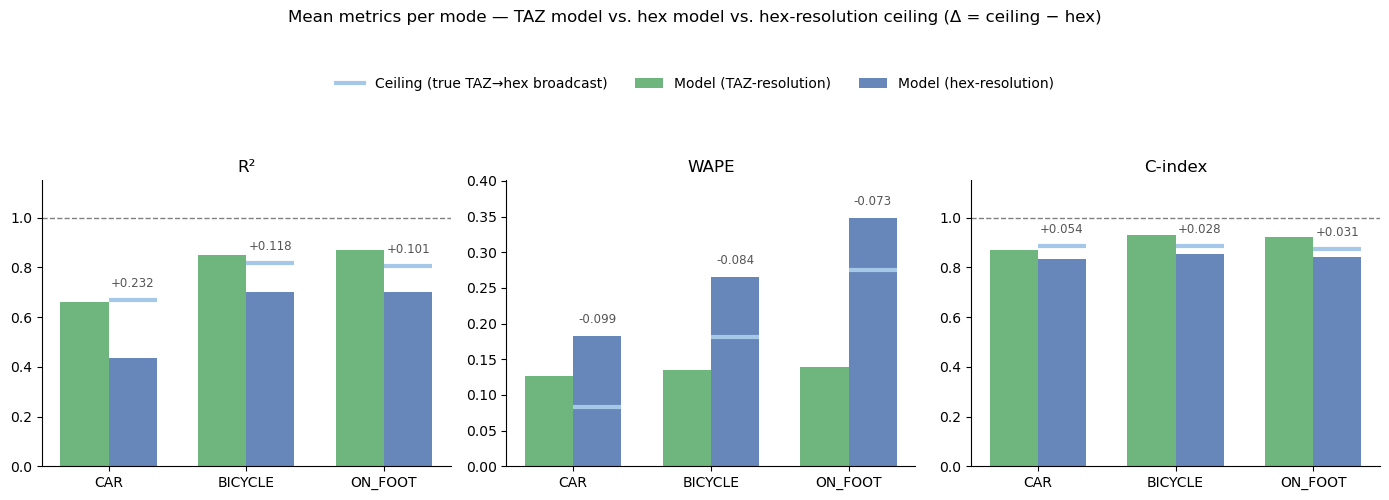

In [26]:
METRICS_SUMMARY = ['r2', 'wape', 'c_index']
METRIC_LABELS = {'r2': 'R²', 'wape': 'WAPE', 'c_index': 'C-index'}
METRICS_WITH_MAX_1 = {'r2', 'c_index'}  # WAPE's ideal is 0, not 1 - no max-possible line for it

COLOR_TAZ = '#55A868'
COLOR_HEX = '#4C72B0'      # darker blue = the actual hex-resolution model
COLOR_CEILING = '#A6C8E8'  # lighter shade of the SAME blue - visually tied to the hex bar it belongs to
BAR_WIDTH = 0.35
x = np.arange(len(TRANSPORT_MODES))


def per_mode_mean(per_channel_dict, mode, metric):
    vals = [m[metric] for col, m in per_channel_dict.items()
            if col.startswith(f"cumulative_accessibility_{mode}_")]
    return np.nanmean(vals)


fig, axes = plt.subplots(1, len(METRICS_SUMMARY), figsize=(14, 4.5))

for ax, metric in zip(axes, METRICS_SUMMARY):
    taz_means     = np.array([per_mode_mean(results["taz"]["absolute"]["per_channel"], mode, metric)
                               for mode in TRANSPORT_MODES])
    hex_means     = np.array([per_mode_mean(results["hex"], mode, metric) for mode in TRANSPORT_MODES])
    ceiling_means = np.array([per_mode_mean(results["ceiling"], mode, metric) for mode in TRANSPORT_MODES])

    x_taz = x - BAR_WIDTH / 2
    x_hex = x + BAR_WIDTH / 2

    ax.bar(x_taz, taz_means, width=BAR_WIDTH, color=COLOR_TAZ, alpha=0.85, zorder=2,
           label='Model (TAZ-resolution)')
    ax.bar(x_hex, hex_means, width=BAR_WIDTH, color=COLOR_HEX, alpha=0.85, zorder=2,
           label='Model (hex-resolution)')

    # ceiling only applies to the hex bar (same target resolution) - draw it only over that bar's width
    for xi, cv in zip(x_hex, ceiling_means):
        ax.plot([xi - BAR_WIDTH / 2, xi + BAR_WIDTH / 2], [cv, cv],
                color=COLOR_CEILING, linewidth=3, solid_capstyle='butt', zorder=3)
    ax.plot([], [], color=COLOR_CEILING, linewidth=3, label='Ceiling (true TAZ→hex broadcast)')

    top = np.maximum.reduce([taz_means, hex_means, ceiling_means])
    if metric in METRICS_WITH_MAX_1:
        top = np.append(top, 1.0)
    ymax = top.max() * 1.15
    ax.set_ylim(0, ymax)
    label_pad = 0.035 * ymax
    for xi, hv, cv in zip(x_hex, hex_means, ceiling_means):
        gap = cv - hv
        ax.text(xi, max(hv, cv) + label_pad, f'{gap:+.3f}', ha='center', va='bottom',
                fontsize=8.5, color='#555555')

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color='gray', linewidth=1, linestyle='--', zorder=1)

    ax.set_xticks(x); ax.set_xticklabels(TRANSPORT_MODES)
    ax.set_title(METRIC_LABELS[metric])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.80])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)
fig.suptitle('Mean metrics per mode — TAZ model vs. hex model vs. hex-resolution ceiling (Δ = ceiling − hex)', y=1.1)
plt.show()